<a href="https://colab.research.google.com/github/SaraAly28/healthcare-data-analysis/blob/main/Diabetes_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# ==========================================================
# Diabetes Risk Analysis Using Machine Learning
# Author: Sara Aly
# ==========================================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots in notebook
%matplotlib inline

# Load dataset
df = pd.read_csv("diabetes.csv")

# Show first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 1. Dataset Overview

This section introduces the diabetes dataset and examines its size, variables, data types, and summary statistics. Understanding the structure of the dataset is an essential first step before performing data cleaning and machine learning analysis.

In [22]:
# ==========================================
# Dataset Overview
# ==========================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape:
(768, 9)

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Summary Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# 2. Data Quality Assessment

Before building a machine learning model, the dataset must be inspected for missing values and impossible measurements.

In this dataset, several medical variables such as BMI, Blood Pressure, Skin Thickness, Insulin, and Glucose should never be zero in real patients. Therefore, these values will be investigated as potential missing observations.

In [23]:
# Check missing values

print("Missing values:")
print(df.isnull().sum())

print("\n")

# Count zero values in important medical columns

columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns:
    print(f"{column}: {(df[column] == 0).sum()} zero values")

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


# 3. Data Cleaning

Several variables contain impossible zero values. These values are treated as missing observations and replaced with the median of each variable. The median is preferred because it is less sensitive to extreme values than the mean.

In [24]:
# Replace impossible zeros with the median

columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns:
    median = df[column].replace(0, np.nan).median()
    df[column] = df[column].replace(0, median)

print("Data cleaned successfully!")

print("\nRemaining zero values:")

for column in columns:
    print(column, (df[column] == 0).sum())

Data cleaned successfully!

Remaining zero values:
Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0


# 4. Distribution of Clinical Variables

Visualizing the distribution of clinical variables helps identify skewness, outliers, and overall data patterns before machine learning.

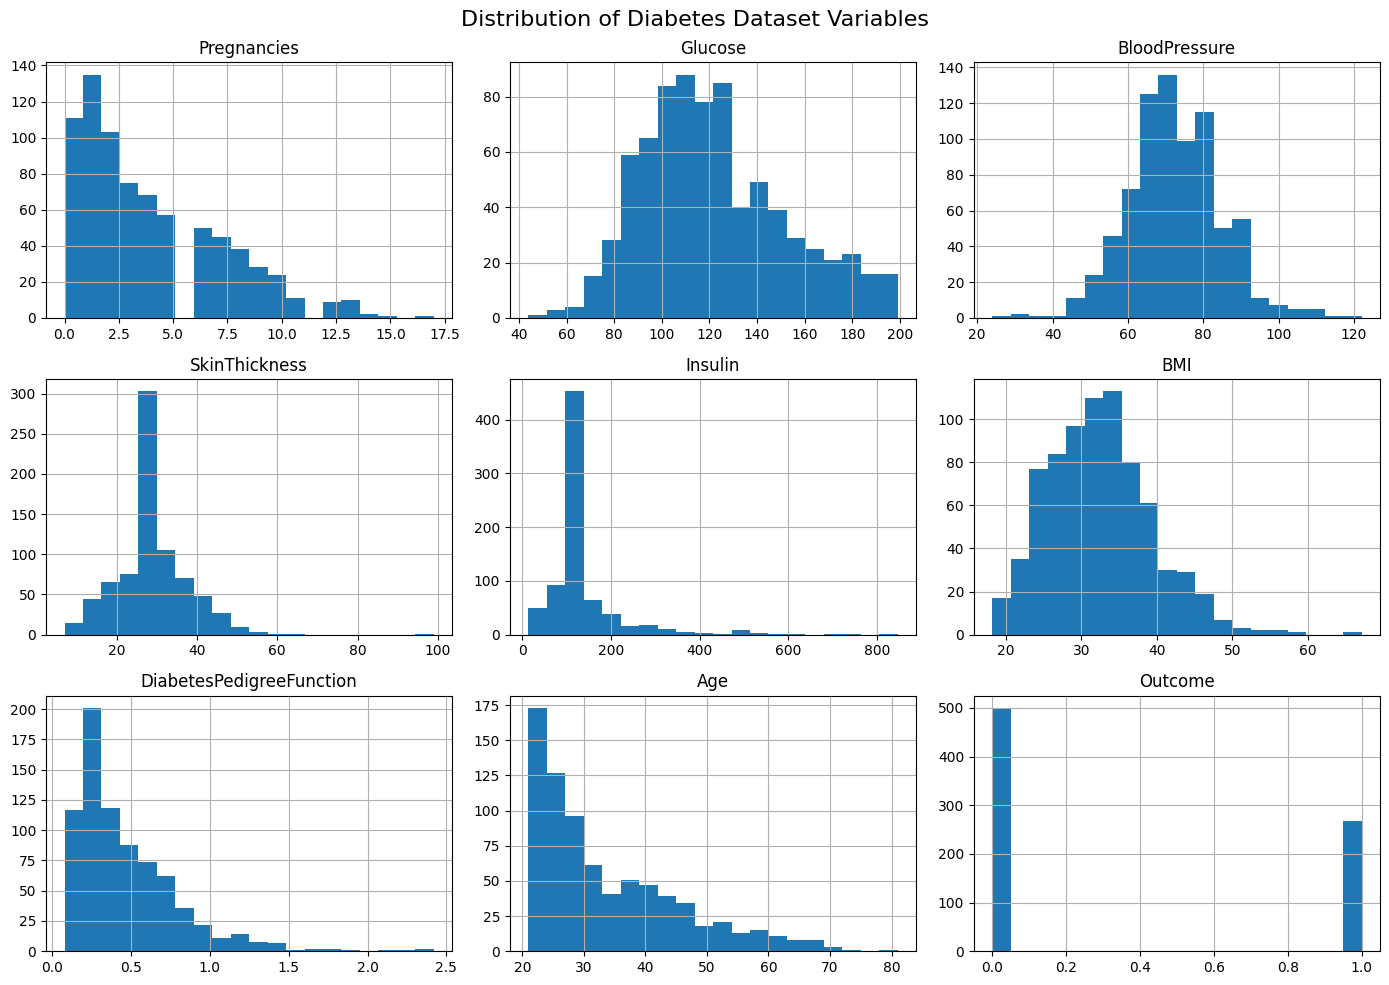

In [25]:
# Histograms of all variables

df.hist(figsize=(14,10), bins=20)

plt.suptitle("Distribution of Diabetes Dataset Variables", fontsize=16)

plt.tight_layout()

plt.show()

# 5. Correlation Analysis

A correlation matrix was generated to investigate the relationships between the clinical variables. Understanding these relationships helps identify which features are most strongly associated with diabetes and can guide feature selection for machine learning models.

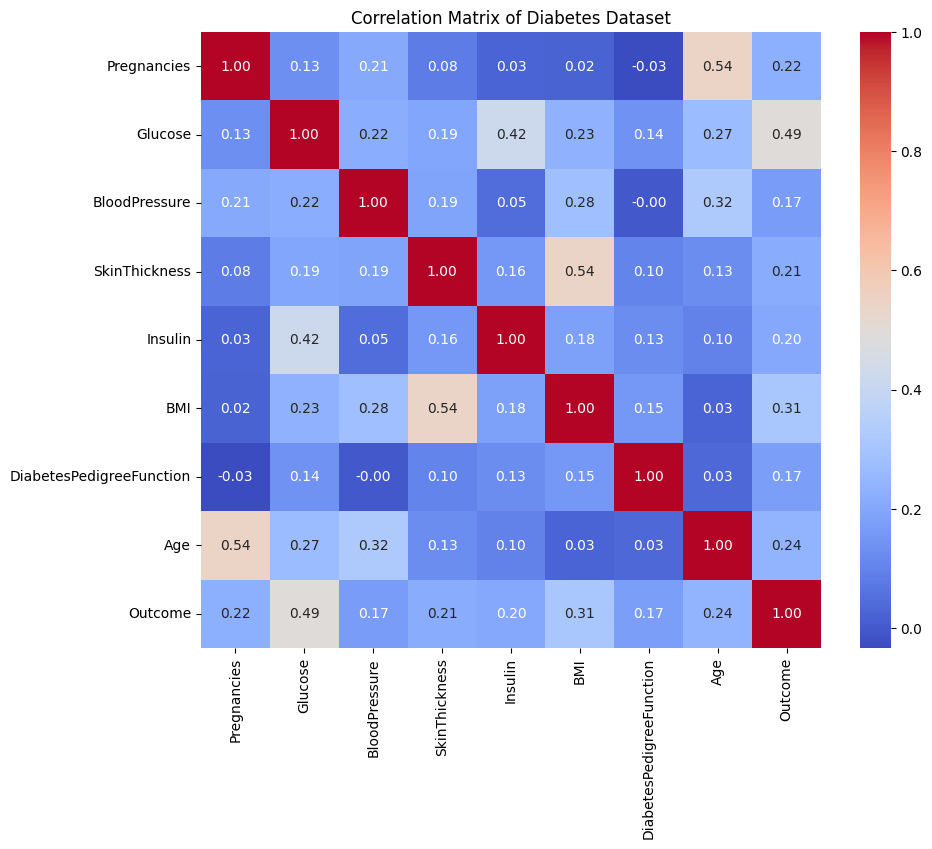

In [26]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Diabetes Dataset")

plt.show()

# 6. Comparing Patients With and Without Diabetes

This section compares the distribution of important clinical measurements between patients diagnosed with diabetes and those without diabetes. These visualizations help identify variables that differ significantly between the two groups.

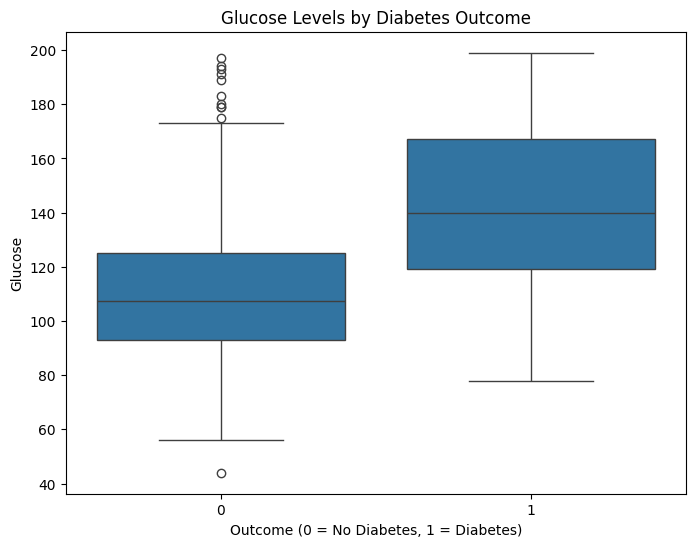

In [27]:
# Glucose vs Diabetes Outcome

plt.figure(figsize=(8,6))

sns.boxplot(
    x="Outcome",
    y="Glucose",
    data=df
)

plt.title("Glucose Levels by Diabetes Outcome")

plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")

plt.ylabel("Glucose")

plt.show()

## 7. Body Mass Index (BMI) and Diabetes

Body Mass Index (BMI) is an important clinical indicator associated with metabolic disorders. This visualization compares BMI distributions between diabetic and non-diabetic patients.

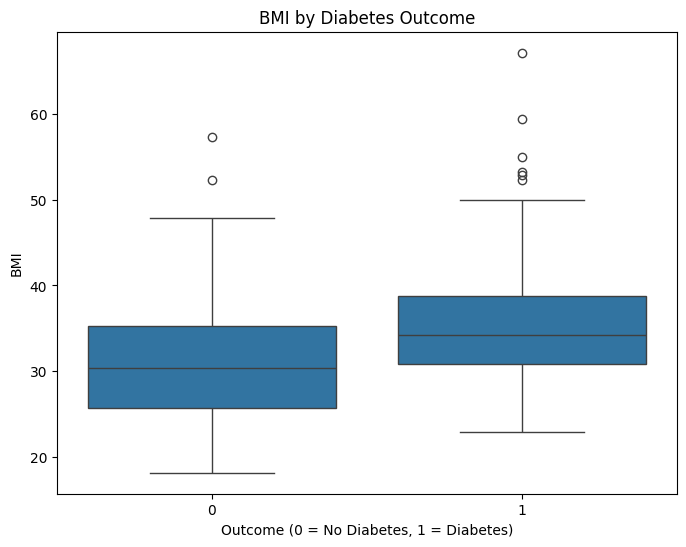

In [28]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Outcome",
    y="BMI",
    data=df
)

plt.title("BMI by Diabetes Outcome")

plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")

plt.ylabel("BMI")

plt.show()

## 8. Age Distribution by Diabetes Status

Age is an important risk factor for diabetes. This analysis compares the age distribution between diabetic and non-diabetic patients to determine whether diabetes is more common among older individuals.

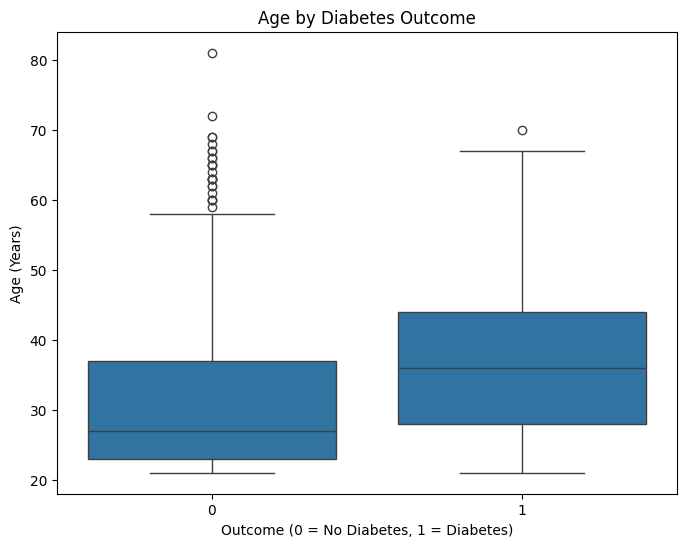

In [29]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Outcome",
    y="Age",
    data=df
)

plt.title("Age by Diabetes Outcome")

plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")

plt.ylabel("Age (Years)")

plt.show()

## 9. Insulin Levels by Diabetes Status

Insulin is a key hormone involved in glucose regulation. This visualization compares insulin levels between diabetic and non-diabetic patients to investigate potential differences between the two groups.

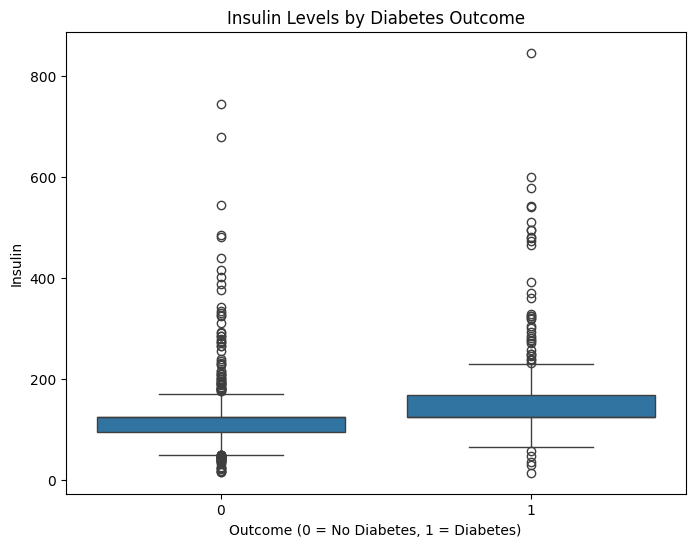

In [30]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Outcome",
    y="Insulin",
    data=df
)

plt.title("Insulin Levels by Diabetes Outcome")

plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")

plt.ylabel("Insulin")

plt.show()

# 10. Machine Learning Model

The objective of this section is to build a machine learning model capable of predicting diabetes based on clinical measurements. Logistic Regression was selected as the baseline classification model because it is widely used in healthcare research due to its interpretability.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [32]:
# Features and target

X = df.drop("Outcome", axis=1)

y = df["Outcome"]

print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 614
Testing samples: 154


In [34]:
# Train Logistic Regression model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [35]:
# Predict on test data

y_pred = model.predict(X_test)

print(y_pred[:10])# Predict on test data

y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 1 1]
[0 0 0 0 0 0 0 0 1 1]


In [36]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 75.32%


In [37]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[82 17]
 [21 34]]


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



# 5. Random Forest Classification

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. In this section, the Random Forest classifier is trained on the diabetes dataset and evaluated using accuracy, a confusion matrix, and a classification report. The results are then compared with the Logistic Regression model to determine which algorithm performs better for diabetes prediction.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7467532467532467

Confusion Matrix:
[[78 21]
 [18 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

